In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')


In [59]:
car_dataset = pd.read_csv('../data/Prepared/prep_model.csv')

In [60]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48050 entries, 0 to 48049
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            48050 non-null  object 
 1   model_clean      48050 non-null  object 
 2   mileage          48050 non-null  float64
 3   engine_volume_l  48050 non-null  float64
 4   fuel_type        48050 non-null  object 
 5   transmission     48050 non-null  object 
 6   body_type        48050 non-null  object 
 7   condition        48050 non-null  object 
 8   owners_count     48050 non-null  float64
 9   region           48050 non-null  object 
 10  color            48050 non-null  object 
 11  price_usd        48050 non-null  float64
 12  district         48050 non-null  object 
 13  age              48050 non-null  float64
dtypes: float64(5), object(9)
memory usage: 5.1+ MB


Text(0.5, 1.0, 'Feature Correlation')

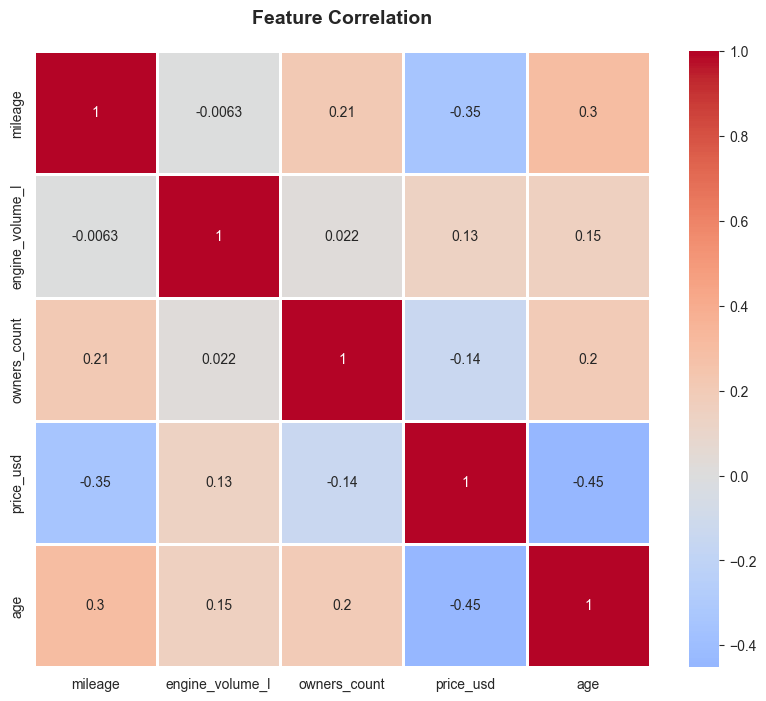

In [61]:
plt.figure(figsize = (10,8))
numeric_data = car_dataset.select_dtypes(include=[np.number])
correlation = numeric_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Feature Correlation', fontsize = 14, fontweight = 'bold', pad=20)

By looking at the chart H and Price USD has a negative correlation it makes sense because when car gets older, it's price will go down generally.and there is another correlation between a price USD and mileage. It also makes sense if car use it more often mileage will go up and Priceville decrease. And another one for age in mileage, for example if car gets sold logically mileage will increase.

In [62]:
car_dataset.columns

Index(['brand', 'model_clean', 'mileage', 'engine_volume_l', 'fuel_type',
       'transmission', 'body_type', 'condition', 'owners_count', 'region',
       'color', 'price_usd', 'district', 'age'],
      dtype='object')

Text(0, 0.5, 'Price')

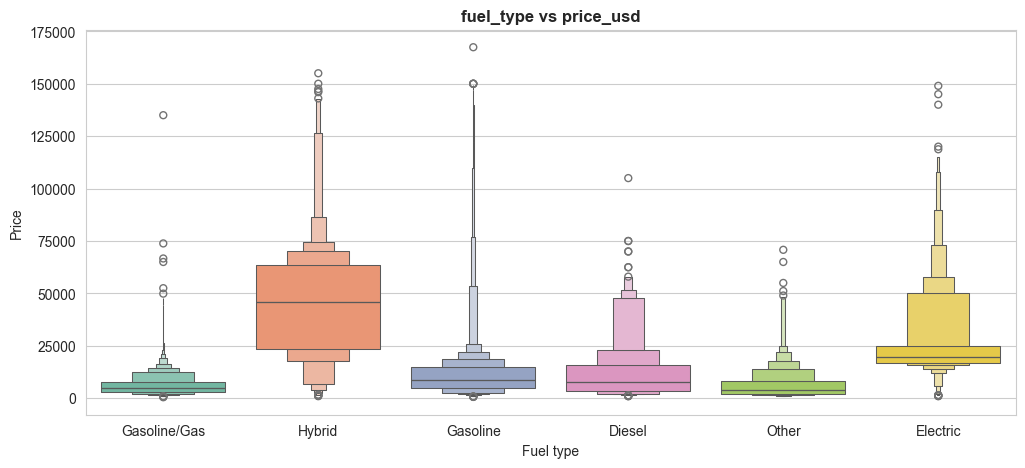

In [63]:
# fuel_type vs price_usd
plt.figure(figsize = (12,5))
sns.boxenplot(x = 'fuel_type', y='price_usd', data=car_dataset, palette='Set2')
plt.title('fuel_type vs price_usd', fontweight = 'bold')
plt.xlabel('Fuel type')
plt.ylabel('Price')

By looking at the chart, we can see gasoline with gas has the lowest median which is around 5000. Gasoline has a median around $9000. It makes sense somehow hybrid cars have the highest median which is $45,000.

In [64]:
car_dataset[car_dataset['transmission']=='Other']

,brand,model_clean,mileage,engine_volume_l,fuel_type,transmission,body_type,condition,owners_count,region,color,price_usd,district,age
31,Other,2125 Комби,24000.0,1.965,Other,Other,Other,Excellent,1.0,Karakalpakstan,White,1250.0,Tahtakupyr,36.0
368,Lada,2106,98365.0,1.100,Gasoline,Other,Other,Average,2.0,Tashkent,Red,1000.0,Zangiata,45.0
530,Volkswagen,Jetta,274931.5,1.500,Gasoline,Other,Sedan,Average,2.0,Tashkent,Red,1000.0,Yakkasaray,45.0
831,Lada,2106,98365.0,2.110,Other,Other,Sedan,Excellent,1.0,Bukhara,Gold,1333.3,Zhondor,32.0
1002,Other,Другая,24000.0,1.600,Other,Other,Other,Excellent,1.0,Navoi,Red,1200.0,Kyzyltepa,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46740,Other,GLE 450,60000.0,3.000,Other,Other,Sedan,Excellent,1.0,Tashkent,Gray,1800.0,Sergeli,4.0
46870,Other,Другая,24000.0,1.000,Gasoline/Gas,Other,Other,Good,4.0,Kashkadarya,Blue,2000.0,Karshi,44.0
46875,Lada,2106,94677.0,6.000,Gasoline/Gas,Other,Minivan,Good,4.0,Samarkand,White,2000.0,Samarkand,26.0
47230,Daewoo,Damas,179000.0,3.000,Other,Other,Other,Good,3.0,Khorezm,White,2083.3,Hiva,18.0


In [65]:
car_dataset.loc[
    (car_dataset["transmission"] == "Other") & 
    (car_dataset["fuel_type"].isin(["Electric", "Hybrid"])),
    "transmission"
] = "EV/Hybrid"

car_dataset["transmission"] = car_dataset["transmission"].replace("Other", "Unknown")

Text(0, 0.5, 'Price')

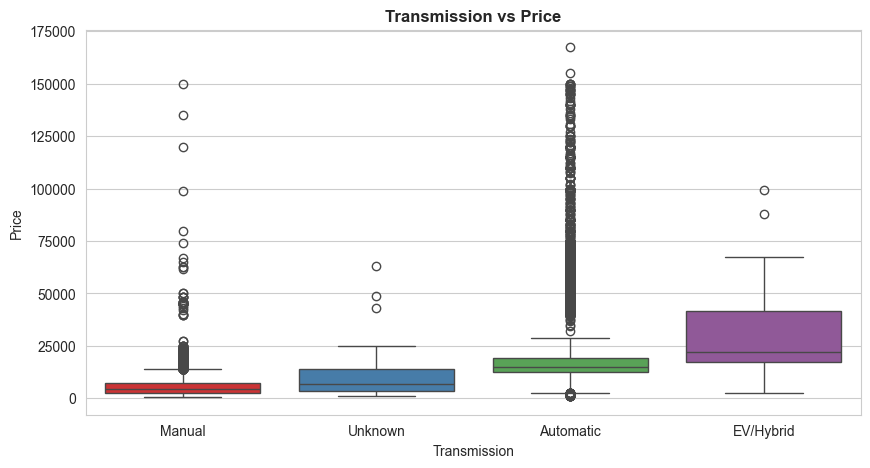

In [66]:
# Transmissions vs Price
plt.figure(figsize=(10,5))
sns.boxplot(x = 'transmission', y = 'price_usd', data=car_dataset, palette='Set1')
plt.title('Transmission vs Price', fontweight = 'bold')
plt.xlabel('Transmission')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

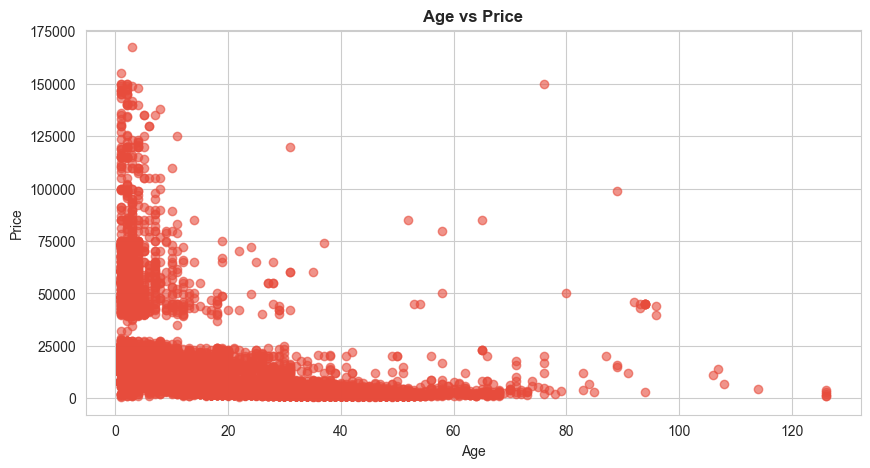

In [67]:
# age vs price
plt.figure(figsize=(10,5))
plt.scatter(car_dataset['age'], car_dataset['price_usd'], alpha=0.6, c = '#e74c3c')
plt.title('Age vs Price', fontweight = 'bold')
plt.xlabel('Age')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

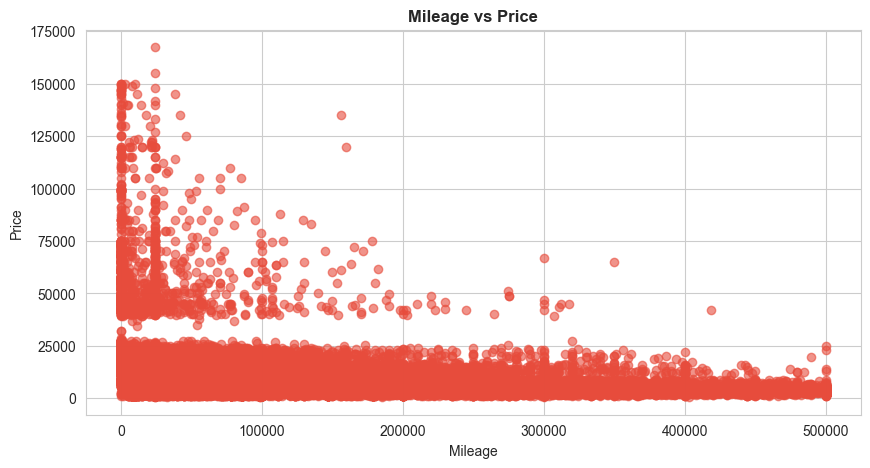

In [68]:
# mileage vs price
plt.figure(figsize=(10,5))
plt.scatter(car_dataset['mileage'], car_dataset['price_usd'], alpha=0.6, c = '#e74c3c')
plt.title('Mileage vs Price', fontweight = 'bold')
plt.xlabel('Mileage')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

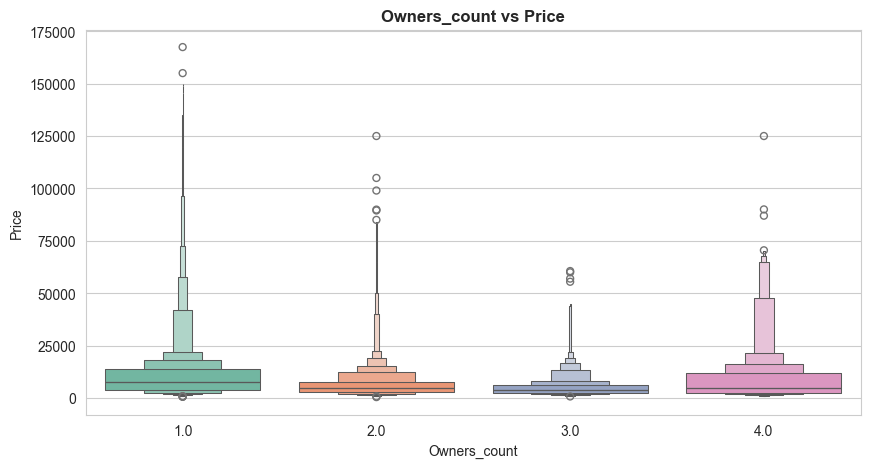

In [69]:
# Owner Count vs price
plt.figure(figsize=(10,5))
sns.boxenplot(x = 'owners_count', y='price_usd', data=car_dataset, palette='Set2')
plt.title('Owners_count vs Price', fontweight = 'bold')
plt.xlabel('Owners_count')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

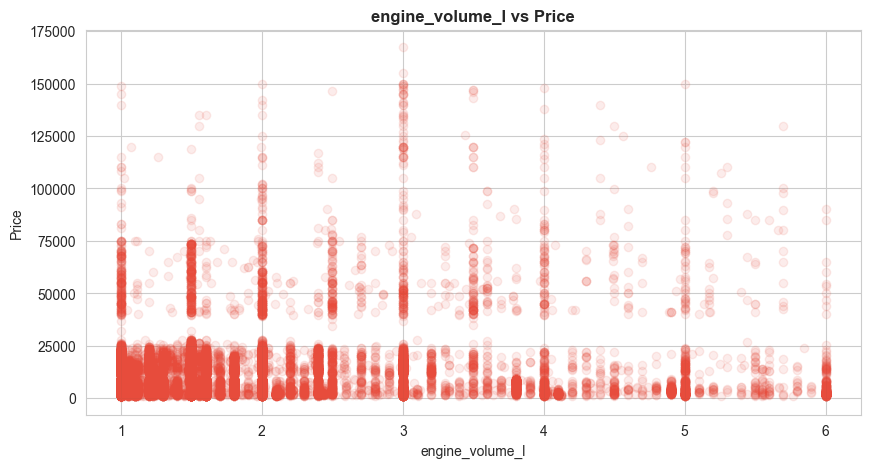

In [70]:
# engine_volume_l vs price 
plt.figure(figsize=(10,5))
plt.scatter(car_dataset['engine_volume_l'], car_dataset['price_usd'], alpha=0.1, c = '#e74c3c')
plt.title('engine_volume_l vs Price', fontweight = 'bold')
plt.xlabel('engine_volume_l')
plt.ylabel('Price')

In [71]:
categorical_features = [
    'brand',
    'model_clean',
    'fuel_type',
    'transmission',
    'body_type',
    'condition',
    'region',
    'color',
    'district'
]

In [72]:
print(car_dataset['condition'].value_counts())

condition
Excellent       26219
Good            18028
Average          3607
Needs Repair      196
Name: count, dtype: int64


In [73]:
condition_order = {'Needs Repair': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
car_dataset['condition'] = car_dataset['condition'].map(condition_order).astype(int)

In [74]:
car_dataset.head()

,brand,model_clean,mileage,engine_volume_l,fuel_type,transmission,body_type,condition,owners_count,region,color,price_usd,district,age
0,Lada,2103,98365.0,1.20,Gasoline/Gas,Manual,Sedan,2,2.0,Jizzakh,Red,1250.0,Gallaaral,47.0
1,Lada,2105,72122.0,1.00,Gasoline/Gas,Manual,Sedan,1,1.0,Namangan,Green,1250.0,Namangan,44.0
2,Lada,2101,98365.0,2.10,Gasoline/Gas,Manual,Convertible,2,4.0,Khorezm,White,1250.0,Karaul,47.0
3,GAZ,31029,147000.0,1.05,Gasoline/Gas,Manual,Station Wagon,2,2.0,Jizzakh,White,1250.0,Mardzhanbulak,30.0
4,Other,626,24000.0,1.60,Gasoline/Gas,Manual,Hatchback,0,1.0,Karakalpakstan,White,1250.0,Kungrad,40.0


In [75]:
car_dataset = car_dataset[
    (car_dataset["age"].between(0, 45)) &
    (car_dataset["price_usd"].between(500, 100000))
].copy()

In [76]:
car_dataset

,brand,model_clean,mileage,engine_volume_l,fuel_type,transmission,body_type,condition,owners_count,region,color,price_usd,district,age
1,Lada,2105,72122.0,1.00,Gasoline/Gas,Manual,Sedan,1,1.0,Namangan,Green,1250.0,Namangan,44.0
3,GAZ,31029,147000.0,1.05,Gasoline/Gas,Manual,Station Wagon,2,2.0,Jizzakh,White,1250.0,Mardzhanbulak,30.0
4,Other,626,24000.0,1.60,Gasoline/Gas,Manual,Hatchback,0,1.0,Karakalpakstan,White,1250.0,Kungrad,40.0
5,Lada,2109,98365.0,1.50,Gasoline/Gas,Manual,Station Wagon,2,1.0,Kashkadarya,White,1250.0,Yangi-Nishan,33.0
6,Lada,2108,98365.0,1.50,Gasoline/Gas,Manual,Station Wagon,2,1.0,Namangan,Turquoise,1250.0,Namangan,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48045,Daewoo,Matiz,179000.0,1.11,Gasoline/Gas,Manual,Other,2,1.0,Karakalpakstan,White,2500.0,Hodzheyli,17.0
48046,Daewoo,Nexia,179000.0,1.50,Gasoline/Gas,Manual,Hatchback,3,1.0,Bukhara,White,2500.0,Bukhara,28.0
48047,Other,Transit,24000.0,2.00,Diesel,Manual,Sedan,2,1.0,Navoi,Blue,2500.0,Navoi,35.0
48048,Daewoo,Matiz,286000.0,1.00,Gasoline,Manual,Hatchback,2,1.0,Tashkent,White,2500.0,Yashnabad,22.0


## Build a prediction pipeline

This section uses `ColumnTransformer` to handle numeric and categorical columns differently. Numeric columns are scaled, and categorical columns are converted with `OneHotEncoder`.

In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [78]:
# Keep the modeling data separate from the original dataframe.
df_model = car_dataset.copy()

# Optional: remove very extreme rows so the first model learns the normal used-car market.
df_model = df_model[
    (df_model["age"].between(0, 45)) &
    (df_model["price_usd"].between(500, 100000))
].copy()

df_model.shape

(46683, 14)

In [79]:
# Group rare model/district values to avoid creating too many one-hot columns.
def group_rare_values(series, min_count=100):
    counts = series.value_counts()
    common_values = counts[counts >= min_count].index
    return series.where(series.isin(common_values), "Other")

for column in ["model_clean", "district"]:
    df_model[column] = group_rare_values(df_model[column], min_count=100)

In [80]:
numeric_features = [
    "mileage",
    "engine_volume_l",
    "owners_count",
    "age",
    "condition",
]

categorical_features = [
    "brand",
    "model_clean",
    "fuel_type",
    "transmission",
    "body_type",
    "region",
    "color",
    "district",
]

X = df_model[numeric_features + categorical_features]
y = df_model["price_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((37346, 13), (9337, 13))

In [81]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", one_hot_encoder),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

In [82]:
# Ridge is a linear regression model that works well with many one-hot encoded columns.
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0)),
])

model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

In [83]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R2:   {r2:.3f}")

MAE:  $2,838
RMSE: $5,602
R2:   0.668


In [84]:
results = pd.DataFrame({
    "actual_price": y_test,
    "predicted_price": y_pred,
})

results["error"] = results["actual_price"] - results["predicted_price"]
results

,actual_price,predicted_price,error
1586,1400.0,3121.038210,-1721.038210
11000,5800.0,5283.546626,516.453374
33064,12250.0,14507.507977,-2257.507977
24153,4333.3,3417.437260,915.862740
19707,8200.0,11290.784508,-3090.784508
...,...,...,...
26788,4500.0,10988.659490,-6488.659490
4956,2200.0,4627.872518,-2427.872518
41252,16000.0,15228.765670,771.234330
18509,7800.0,10497.905338,-2697.905338


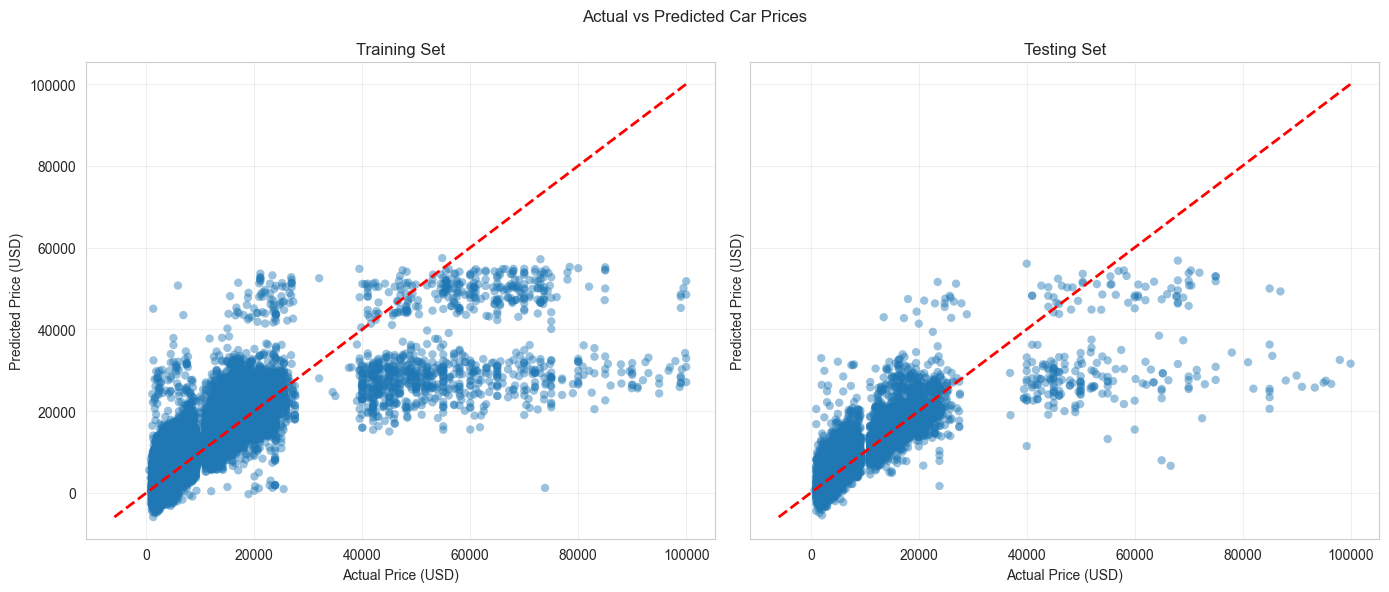

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

plots = [
    (axes[0], y_train, y_train_pred, "Training Set"),
    (axes[1], y_test, y_pred, "Testing Set"),
]

min_price = min(y_train.min(), y_test.min(), y_train_pred.min(), y_pred.min())
max_price = max(y_train.max(), y_test.max(), y_train_pred.max(), y_pred.max())

for ax, actual, predicted, title in plots:
    ax.scatter(actual, predicted, alpha=0.45, edgecolor="none")
    ax.plot([min_price, max_price], [min_price, max_price], color="red", linestyle="--", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Actual Price (USD)")
    ax.set_ylabel("Predicted Price (USD)")
    ax.grid(True, alpha=0.3)

fig.suptitle("Actual vs Predicted Car Prices")
plt.tight_layout()
plt.show()

## Compare several regression models

The first Ridge model is a useful baseline. These additional models can capture nonlinear relationships in car prices.

In [86]:
models = {
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
}

model_results = []
trained_models = {}

for name, regressor in models.items():
    candidate_model = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("regressor", regressor),
    ])
    
    candidate_model.fit(X_train, y_train)
    train_predictions = candidate_model.predict(X_train)
    test_predictions = candidate_model.predict(X_test)
    
    model_results.append({
        "model": name,
        "train_mae": mean_absolute_error(y_train, train_predictions),
        "test_mae": mean_absolute_error(y_test, test_predictions),
        "test_rmse": mean_squared_error(y_test, test_predictions) ** 0.5,
        "test_r2": r2_score(y_test, test_predictions),
    })
    trained_models[name] = candidate_model

model_comparison = (
    pd.DataFrame(model_results)
    .sort_values("test_rmse")
    .reset_index(drop=True)
)

model_comparison

,model,train_mae,test_mae,test_rmse,test_r2
0,Random Forest,840.853787,1525.229100,3963.072561,0.833936
1,Extra Trees,580.313657,1561.940872,4089.943792,0.823133
2,Ridge,2860.841676,2838.223331,5601.608874,0.668230


In [87]:
best_model_name = model_comparison.loc[0, "model"]
best_model = trained_models[best_model_name]

best_train_pred = best_model.predict(X_train)
best_test_pred = best_model.predict(X_test)

print(f"Best model: {best_model_name}")
print(f"Test MAE:  ${mean_absolute_error(y_test, best_test_pred):,.0f}")
print(f"Test RMSE: ${mean_squared_error(y_test, best_test_pred) ** 0.5:,.0f}")
print(f"Test R2:   {r2_score(y_test, best_test_pred):.3f}")

Best model: Random Forest
Test MAE:  $1,525
Test RMSE: $3,963
Test R2:   0.834


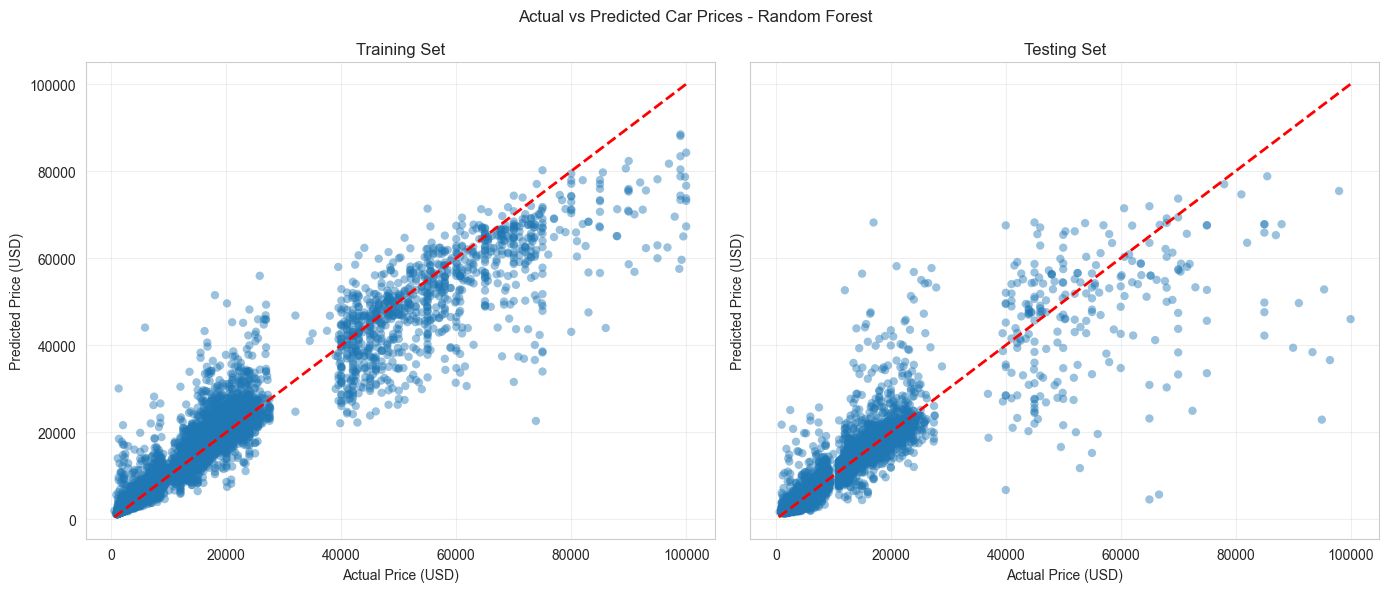

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

plots = [
    (axes[0], y_train, best_train_pred, "Training Set"),
    (axes[1], y_test, best_test_pred, "Testing Set"),
]

min_price = min(y_train.min(), y_test.min(), best_train_pred.min(), best_test_pred.min())
max_price = max(y_train.max(), y_test.max(), best_train_pred.max(), best_test_pred.max())

for ax, actual, predicted, title in plots:
    ax.scatter(actual, predicted, alpha=0.45, edgecolor="none")
    ax.plot([min_price, max_price], [min_price, max_price], color="red", linestyle="--", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Actual Price (USD)")
    ax.set_ylabel("Predicted Price (USD)")
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Actual vs Predicted Car Prices - {best_model_name}")
plt.tight_layout()
plt.show()